# Curaduría y Preprocesamiento de Datos — Proyecto BI-RADS
**Sistema de Auditoría de Coherencia Diagnóstica con BETO**  
Doctorado en Ciencias e Ingeniería para la Salud — Universidad de Valparaíso, 2025  
Autores: Robinson Moreno - Sebastián Inostroza


| Sección | Contenido |
|---------|-----------|
| 1 | Verificación de entorno y librerías |
| 2 | Carga del dataset |
| 3 | Inspección inicial |
| 4 | Análisis de valores faltantes |
| 5 | Tratamiento de nulos |
| 6 | Preprocesamiento de texto |
| 7 | Distribución de clases BI-RADS (EDA) |
| 8 | EDA de variables clínicas estructuradas |
| 9 | Análisis de tokens BETO + umbral 512 |
| 10 | Detección de duplicados y riesgo de leakage |
| 11 | Construcción de columnas para modelos |
| 12 | División del dataset (train/val/test) |
| 13 | Pesos de clase para manejo del desbalance |
| 14 | Verificación visual de estratificación |
| 15 | Exportación trazable del dataset limpio |
| 16 | Resumen ejecutivo de curaduría |


## 1. Verificación de entorno y librerías

In [ ]:
# Instalación de dependencias (ejecutar solo si es necesario)
# !pip install torch transformers scikit-learn pandas numpy matplotlib seaborn

import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import re
import os
import hashlib
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from transformers import BertTokenizerFast

print(f"✅ PyTorch:        {torch.__version__}")
print(f"✅ Pandas:         {pd.__version__}")
print(f"✅ NumPy:          {np.__version__}")
print(f"✅ Transformers:   instalado correctamente")
print(f"\n🖥️  GPU disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   GPU:           {torch.cuda.get_device_name(0)}")

# Paleta clínica global — usada en todos los gráficos
# Verde = zona segura (BI-RADS 0-3) | Rojo = zona de riesgo (BI-RADS 4-6)
COLORES = {0:'#4A9ECA', 1:'#5BBF8A', 2:'#5BBF8A',
           3:'#F0C040', 4:'#E8764A', 5:'#D94040', 6:'#8B1C1C'}
NOMBRES = {0:'Incompleto', 1:'Negativo', 2:'Benigno',
           3:'Prob. benigno', 4:'Sospechoso',
           5:'Alta sospecha', 6:'Maligno confirmado'}

os.makedirs('figures', exist_ok=True)
os.makedirs('data/processed', exist_ok=True)
print("\n📁 Directorios 'figures/' y 'data/processed/' listos.")


✅ PyTorch:        2.11.0+cpu
✅ Pandas:         2.2.2
✅ NumPy:          2.0.2
✅ Transformers:   instalado correctamente

🖥️  GPU disponible: False

📁 Directorios 'figures/' y 'data/processed/' listos.


## 2. Carga del dataset

In [ ]:
from google.colab import files

repo_path = '/content/proyecto-birads-coherence-audit/data/raw'
csv_name  = 'BIRADS_radiology_reports.csv'
csv_full  = os.path.join(repo_path, csv_name)

if os.path.exists(csv_full):
    df = pd.read_csv(csv_full, sep=';', encoding='utf-8')
    print(f"✅ Dataset cargado desde repositorio: {csv_full}")
else:
    print("⚠️  Archivo no encontrado en el repositorio.")
    print("Por favor sube el archivo 'BIRADS_radiology_reports.csv':")
    uploaded = files.upload()
    if uploaded:
        filename = list(uploaded.keys())[0]
        df = pd.read_csv(filename, sep=';', encoding='utf-8')
        print(f"\n✅ Dataset cargado desde carga manual: {filename}")
    else:
        raise FileNotFoundError("No se proporcionó el archivo CSV.")

print(f"\n📐 Shape: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"📋 Columnas: {list(df.columns)}")


⚠️  Archivo no encontrado en el repositorio.
Por favor sube el archivo 'BIRADS_radiology_reports.csv':


Saving BIRADS_radiology_reports.csv to BIRADS_radiology_reports.csv

✅ Dataset cargado desde carga manual: BIRADS_radiology_reports.csv

📐 Shape: 4357 filas × 15 columnas
📋 Columnas: ['ID_R', 'Year', 'Month', 'Medical_Unit', 'Full_Report', 'LMP', 'Hormonal_Therapy', 'Family_History', 'Reason', 'Observations', 'Conclusion', 'Recommendations', 'BI-RADS', 'Age', 'Children']


## 3. Inspección inicial del dataset

In [ ]:
print("📋 Primeras 2 filas (columnas clave):")
cols_clave = [c for c in ['ID_R', 'Year', 'Age', 'BI-RADS', 'Observations', 'Conclusion']
              if c in df.columns]
print(df[cols_clave].head(2).to_string())

print(f"\n📝 Ejemplo de texto real (primer informe):")
print(f"\nOBSERVACIONES:")
print(df['Observations'].iloc[0])
print(f"\nCONCLUSIÓN:")
print(df['Conclusion'].iloc[0])
print(f"\nBI-RADS ASIGNADO: {df['BI-RADS'].iloc[0]}")

print(f"\n📊 Tipos de datos:")
print(df.dtypes.to_string())


📋 Primeras 2 filas (columnas clave):
       ID_R  Year   Age  BI-RADS                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    Observations                                                                                                                                                                                                                        Conclusion
0  20190101  2019  48.0        0  MAMOGRAFÍA DIGITAL BILATERAL CRÁNEO-CAUDAL Y MEDIO LATERAL OBL

## 4. Análisis de valores faltantes

In [ ]:
print("🔍 Valores faltantes por columna:")
print("─" * 50)
hay_nulos = False
for col in df.columns:
    nulos = df[col].isna().sum()
    if nulos > 0:
        hay_nulos = True
        pct = nulos / len(df) * 100
        tipo = "🔴 CRÍTICO" if col in ['Observations','Conclusion','BI-RADS'] else "🟡 Secundario"
        print(f"  {col:25s}: {nulos:4d} ({pct:.2f}%)  {tipo}")
print("─" * 50)
if not hay_nulos:
    print("  ✅ No se detectaron valores faltantes en ninguna columna.")
print(f"\n  Total de registros: {len(df)}")


🔍 Valores faltantes por columna:
──────────────────────────────────────────────────
  LMP                      :  135 (3.10%)  🟡 Secundario
  Recommendations          :   10 (0.23%)  🟡 Secundario
  Age                      :   15 (0.34%)  🟡 Secundario
  Children                 :  125 (2.87%)  🟡 Secundario
──────────────────────────────────────────────────

  Total de registros: 4357


## 5. Tratamiento de valores faltantes

**Criterio aplicado:**
- Nulos en columnas de texto crítico (`Observations`, `Conclusion`): **eliminación de fila** — un informe sin texto no puede entrenarse.
- Nulos en variables clínicas numéricas (`Age`): **imputación por mediana** — preserva registros sin introducir sesgo de media.


In [ ]:
n_antes = len(df)

# Nulos en texto (crítico): eliminar la fila completa
df = df[df['Observations'].notna() & df['Conclusion'].notna()].copy()
n_tras_texto = len(df)

# Nulos en Age: imputar mediana (calculada sobre todo el conjunto pre-split)
for col in ['Age']:
    if col in df.columns and df[col].isna().any():
        mediana = df[col].median()
        n_imputados = df[col].isna().sum()
        df[col] = df[col].fillna(mediana)
        print(f"  ✏️  '{col}': {n_imputados} nulos imputados con mediana = {mediana:.0f} años")

eliminados = n_antes - n_tras_texto
print(f"\n🧹 Registros eliminados por nulos en texto: {eliminados}")
print(f"   Dataset antes:  {n_antes}")
print(f"   Dataset después: {len(df)}")
print(f"   Pérdida: {eliminados/n_antes*100:.2f}%")


  ✏️  'Age': 15 nulos imputados con mediana = 51 años

🧹 Registros eliminados por nulos en texto: 0
   Dataset antes:  4357
   Dataset después: 4357
   Pérdida: 0.00%


## 6. Preprocesamiento de texto clínico

**Pasos aplicados:**
1. Normalización de saltos de línea y tabuladores → espacio
2. Colapso de guiones repetidos → espacio
3. Conversión a minúsculas
4. Expansión de abreviaturas anatómicas clínicas del dominio mamario
5. Eliminación de caracteres no útiles (conservando acentos y puntuación clínica)
6. Colapso de espacios múltiples


In [ ]:
# Diccionario de abreviaturas clínicas — dominio mamario español sudamericano
ABREVIATURAS = {
    r'\bcse\b':     'cuadrante superoexterno',
    r'\bcsi\b':     'cuadrante superointerno',
    r'\bcie\b':     'cuadrante inferoexterno',
    r'\bcii\b':     'cuadrante inferointerno',
    r'\bucs\b':     'union de cuadrantes superiores',
    r'\buci\b':     'union de cuadrantes inferiores',
    r'\bucse\b':    'union de cuadrantes superoexternos',
    r'\bgli\b':     'ganglio linfatico intramamario',
    r'\blpm\b':     'ultimo periodo menstrual',
    r'\bfur\b':     'fecha de ultima regla',
    r'\bacr\b':     'american college of radiology',
    r'\bbirads\b':  'bi-rads',
    r'\bmd\b':      'mama derecha',
    r'\bmi\b':      'mama izquierda',
    r'\bcc\b':      'craneocaudal',
    r'\bmlo\b':     'mediolateral oblicua',
}

def limpiar_texto(texto):
    """
    Normaliza texto clínico radiológico en español.
    Retorna string vacío si el input es NaN o vacío.
    """
    if pd.isna(texto) or str(texto).strip() == '':
        return ''
    texto = str(texto)
    texto = re.sub(r'[\r\n\t]+', ' ', texto)          # 1. saltos → espacio
    texto = re.sub(r'-{2,}', ' ', texto)               # 2. guiones repetidos
    texto = texto.lower().strip()                       # 3. minúsculas
    for patron, expansion in ABREVIATURAS.items():      # 4. abreviaturas
        texto = re.sub(patron, expansion, texto)
    texto = re.sub(r'[^a-záéíóúüñ0-9\s\.,;:\-\(\)/]', ' ', texto)  # 5. filtro
    texto = re.sub(r'\s+', ' ', texto).strip()         # 6. espacios
    return texto

# Prueba con ejemplo que contiene abreviaturas
ejemplo = "EN EL CSE DE LA MAMA DERECHA SE VISUALIZA NODULO. GLI EN REGION PECTOAXILAR."
print("ANTES:")
print(ejemplo)
print("\nDESPUÉS:")
print(limpiar_texto(ejemplo))


ANTES:
EN EL CSE DE LA MAMA DERECHA SE VISUALIZA NODULO. GLI EN REGION PECTOAXILAR.

DESPUÉS:
en el cuadrante superoexterno de la mama derecha se visualiza nodulo. ganglio linfatico intramamario en region pectoaxilar.


In [ ]:
# Aplicar limpieza a todo el dataset
df['obs_clean']   = df['Observations'].apply(limpiar_texto)
df['concl_clean'] = df['Conclusion'].apply(limpiar_texto)

print("✅ Limpieza aplicada a los registros")
print(f"\n📏 Estadísticas de longitud (palabras) — obs_clean:")
long_obs = df['obs_clean'].str.split().str.len()
print(f"   Promedio: {long_obs.mean():.0f} palabras")
print(f"   Mínimo:   {long_obs.min():.0f} palabras")
print(f"   Máximo:   {long_obs.max():.0f} palabras")
print(f"   P95:      {long_obs.quantile(.95):.0f} palabras")

# Verificar que no quedaron textos vacíos tras limpieza
vacios_obs   = (df['obs_clean'].str.strip() == '').sum()
vacios_concl = (df['concl_clean'].str.strip() == '').sum()
print(f"\n🔍 Textos vacíos tras limpieza:")
print(f"   obs_clean:   {vacios_obs}")
print(f"   concl_clean: {vacios_concl}")
if vacios_obs > 0 or vacios_concl > 0:
    print("  ⚠️  Existen textos vacíos — considerar eliminación adicional")


✅ Limpieza aplicada a los registros

📏 Estadísticas de longitud (palabras) — obs_clean:
   Promedio: 74 palabras
   Mínimo:   35 palabras
   Máximo:   173 palabras
   P95:      111 palabras

🔍 Textos vacíos tras limpieza:
   obs_clean:   0
   concl_clean: 0


## 7. Distribución de categorías BI-RADS (EDA)

📊 Distribución de categorías BI-RADS:
────────────────────────────────────────────────
  BI-RADS 0 (Incompleto     ):  966 ( 22.2%)  ██████████████████████
  BI-RADS 1 (Negativo       ):  596 ( 13.7%)  █████████████
  BI-RADS 2 (Benigno        ): 2635 ( 60.5%)  ████████████████████████████████████████████████████████████
  BI-RADS 3 (Prob. benigno  ):   87 (  2.0%)  █
  BI-RADS 4 (Sospechoso     ):   52 (  1.2%)  █
  BI-RADS 5 (Alta sospecha  ):   16 (  0.4%)  
  BI-RADS 6 (Maligno confirmado):    5 (  0.1%)  
────────────────────────────────────────────────
  TOTAL: 4357

⚠️  Ratio clase mayoritaria / minoritaria: 527.0x — confirma desbalance severo


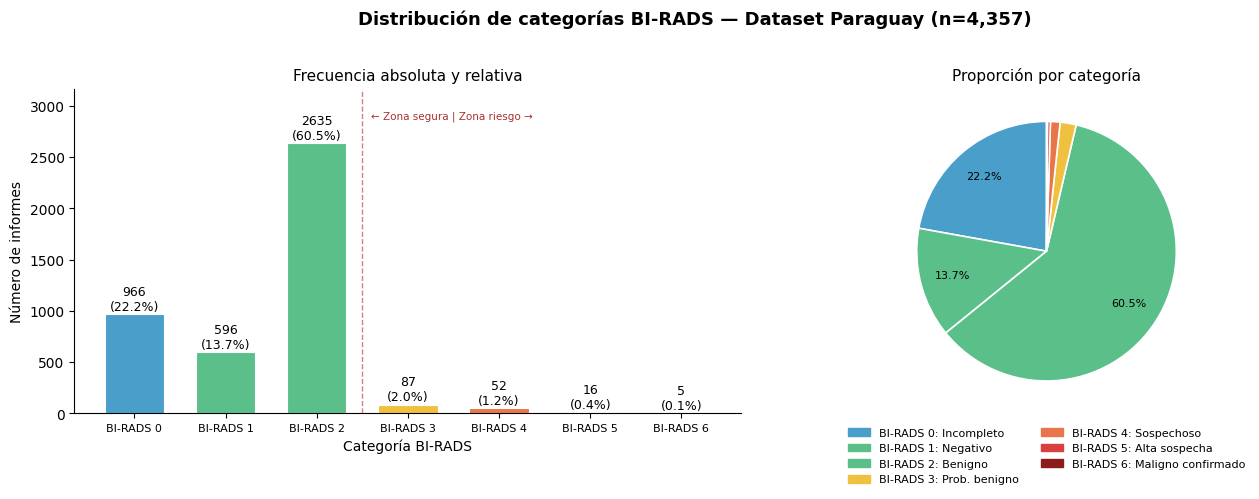

💾 Figura guardada: figures/fig1_distribucion_birads.png


In [ ]:
conteo = df['BI-RADS'].value_counts().sort_index()
categorias = [f"BI-RADS {i}" for i in conteo.index]
colores    = [COLORES[i] for i in conteo.index]

# Texto en consola
print("📊 Distribución de categorías BI-RADS:")
print("─" * 48)
for cat, cant in conteo.items():
    pct   = cant / len(df) * 100
    barra = '█' * int(pct)
    print(f"  BI-RADS {cat} ({NOMBRES[cat]:15s}): {cant:4d} ({pct:5.1f}%)  {barra}")
print("─" * 48)
print(f"  TOTAL: {len(df)}")
print(f"\n⚠️  Ratio clase mayoritaria / minoritaria: "
      f"{conteo.max()/conteo.min():.1f}x — confirma desbalance severo")

# Figura publicable
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"Distribución de categorías BI-RADS — Dataset Paraguay (n={len(df):,})",
             fontsize=13, fontweight='bold', y=1.02)

ax1 = axes[0]
bars = ax1.bar(categorias, conteo.values, color=colores,
               edgecolor='white', linewidth=0.8, width=0.65)
for bar, v in zip(bars, conteo.values):
    pct = v / len(df) * 100
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             f'{v}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)
ax1.set_ylabel("Número de informes", fontsize=10)
ax1.set_xlabel("Categoría BI-RADS", fontsize=10)
ax1.set_title("Frecuencia absoluta y relativa", fontsize=11)
ax1.set_ylim(0, conteo.max() * 1.2)
ax1.spines[['top','right']].set_visible(False)
ax1.tick_params(axis='x', labelsize=8)
ax1.axvline(x=2.5, color='#AA3030', linestyle='--', linewidth=1, alpha=0.6)
ax1.text(2.6, conteo.max()*1.12, '← Zona segura | Zona riesgo →',
         fontsize=7.5, color='#AA3030', va='top')

ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(
    conteo.values, labels=None, colors=colores,
    autopct=lambda p: f'{p:.1f}%' if p > 3 else '',
    startangle=90, pctdistance=0.75,
    wedgeprops={'edgecolor':'white', 'linewidth':1.2})
for at in autotexts:
    at.set_fontsize(8)
ax2.set_title("Proporción por categoría", fontsize=11)
leyenda = [mpatches.Patch(color=COLORES[i], label=f"BI-RADS {i}: {NOMBRES[i]}")
           for i in conteo.index]
ax2.legend(handles=leyenda, loc='lower center', bbox_to_anchor=(0.5, -0.25),
           ncol=2, fontsize=8, frameon=False)

plt.tight_layout()
plt.savefig('figures/fig1_distribucion_birads.png', dpi=300, bbox_inches='tight')
plt.show()
print("💾 Figura guardada: figures/fig1_distribucion_birads.png")


## 8. EDA de variables clínicas estructuradas

Análisis de la relación entre variables demográficas/clínicas y la categoría BI-RADS.  
Esto justifica la futura incorporación de estas variables en el modelo multimodal (Fase 2).


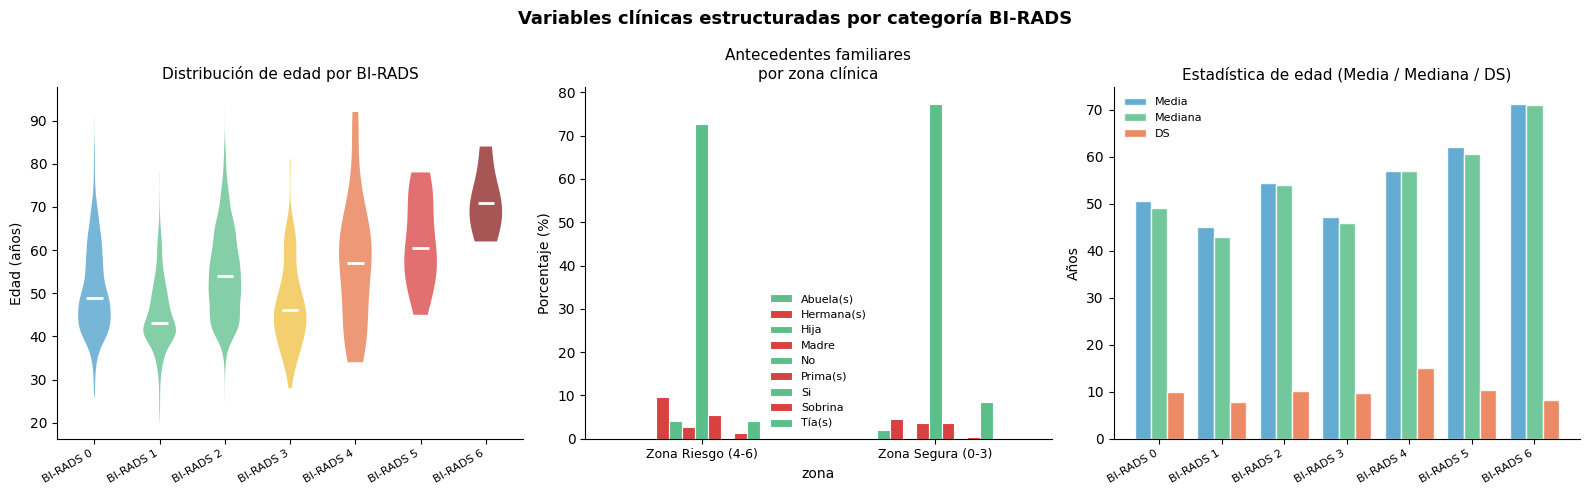

💾 Figura guardada: figures/fig3_variables_clinicas.png

📋 Estadística descriptiva — Edad por BI-RADS:
          count  mean   std   min   25%   50%   75%   max
BI-RADS                                                  
0         966.0  50.6  10.0  26.0  43.0  49.0  57.0  91.0
1         596.0  45.0   7.8  20.0  40.0  43.0  49.0  78.0
2        2635.0  54.5  10.1  25.0  46.0  54.0  61.0  94.0
3          87.0  47.2   9.6  28.0  41.0  46.0  52.5  81.0
4          52.0  57.0  15.0  34.0  44.8  57.0  66.0  92.0
5          16.0  62.1  10.3  45.0  53.5  60.5  70.2  78.0
6           5.0  71.2   8.2  62.0  67.0  71.0  72.0  84.0


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Variables clínicas estructuradas por categoría BI-RADS",
             fontsize=13, fontweight='bold')

# --- 1. Distribución de edad por BI-RADS (violin plot) ---
ax1 = axes[0]
data_edad = [df[df['BI-RADS']==c]['Age'].dropna().values
             for c in sorted(df['BI-RADS'].unique())]
bp = ax1.violinplot(data_edad, showmedians=True, showextrema=False)
for body, c in zip(bp['bodies'], sorted(df['BI-RADS'].unique())):
    body.set_facecolor(COLORES[c])
    body.set_alpha(0.75)
bp['cmedians'].set_color('white')
bp['cmedians'].set_linewidth(2)
ax1.set_xticks(range(1, len(sorted(df['BI-RADS'].unique()))+1))
ax1.set_xticklabels([f"BI-RADS {c}" for c in sorted(df['BI-RADS'].unique())],
                    rotation=30, ha='right', fontsize=8)
ax1.set_ylabel("Edad (años)", fontsize=10)
ax1.set_title("Distribución de edad por BI-RADS", fontsize=11)
ax1.spines[['top','right']].set_visible(False)

# --- 2. Antecedentes familiares por zona clínica ---
ax2 = axes[1]
col_fam = next((c for c in ['Family_History','Historia_Familiar','FamilyHistory']
                if c in df.columns), None)
if col_fam:
    df['zona'] = df['BI-RADS'].apply(lambda x: 'Zona Riesgo (4-6)' if x >= 4 else 'Zona Segura (0-3)')
    tabla = df.groupby(['zona', col_fam]).size().unstack(fill_value=0)
    tabla_pct = tabla.div(tabla.sum(axis=1), axis=0) * 100
    tabla_pct.plot(kind='bar', ax=ax2, color=['#5BBF8A','#D94040'],
                   edgecolor='white', linewidth=0.8)
    ax2.set_title("Antecedentes familiares\npor zona clínica", fontsize=11)
    ax2.set_ylabel("Porcentaje (%)", fontsize=10)
    ax2.set_xticklabels(tabla_pct.index, rotation=0, fontsize=9)
    ax2.spines[['top','right']].set_visible(False)
    ax2.legend(fontsize=8, frameon=False)
else:
    ax2.text(0.5, 0.5, "Columna de antecedentes\nfamiliares no disponible\nen este dataset",
             ha='center', va='center', fontsize=10, color='gray', transform=ax2.transAxes)
    ax2.axis('off')

# --- 3. Estadística descriptiva de edad por BI-RADS ---
ax3 = axes[2]
stats_edad = df.groupby('BI-RADS')['Age'].agg(['mean','median','std']).reset_index()
x = np.arange(len(stats_edad))
w = 0.26
ax3.bar(x - w, stats_edad['mean'],   width=w, label='Media',   color='#4A9ECA', alpha=0.85, edgecolor='white')
ax3.bar(x,     stats_edad['median'], width=w, label='Mediana', color='#5BBF8A', alpha=0.85, edgecolor='white')
ax3.bar(x + w, stats_edad['std'],    width=w, label='DS',      color='#E8764A', alpha=0.85, edgecolor='white')
ax3.set_xticks(x)
ax3.set_xticklabels([f"BI-RADS {int(c)}" for c in stats_edad['BI-RADS']],
                    rotation=30, ha='right', fontsize=8)
ax3.set_ylabel("Años", fontsize=10)
ax3.set_title("Estadística de edad (Media / Mediana / DS)", fontsize=11)
ax3.legend(fontsize=8, frameon=False)
ax3.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('figures/fig3_variables_clinicas.png', dpi=300, bbox_inches='tight')
plt.show()
print("💾 Figura guardada: figures/fig3_variables_clinicas.png")

# Tabla resumen estadística
print("\n📋 Estadística descriptiva — Edad por BI-RADS:")
print(df.groupby('BI-RADS')['Age'].describe().round(1).to_string())


## 9. Análisis de tokens BETO y umbral de 512

BETO (y BERT en general) tiene un límite de **512 tokens** por secuencia.  
Es fundamental medir cuántos informes superan ese umbral para decidir la **estrategia de truncación** antes del entrenamiento.

**Estrategias posibles:**
- `head`: primeros 512 tokens (puede perder la conclusión)
- `tail`: últimos 512 tokens
- `head+tail` ⭐: primeros 128 + últimos 384 — estándar recomendado en NLP clínico


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/364 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/242k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/480k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

⏳ Tokenizando informes — esto puede tardar ~1 minuto en Colab...


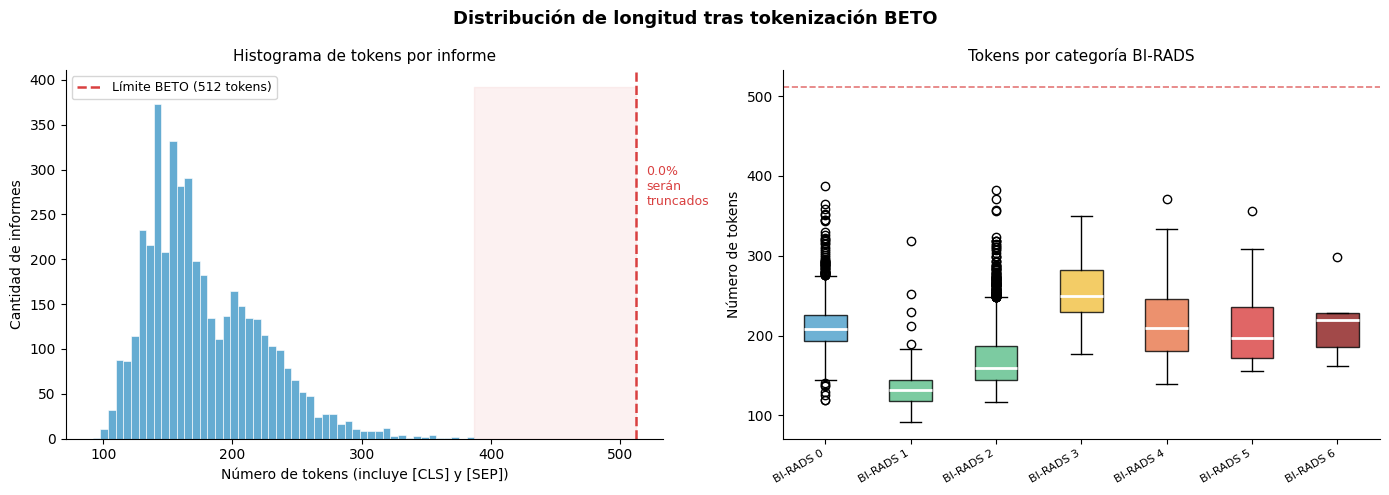

💾 Figura guardada: figures/fig2_longitud_tokens.png

📊 Estadísticas de tokens:
   Mediana:        166 tokens
   Percentil 95:  259 tokens
   Máximo:        387 tokens
   > 512 tokens:  0 informes (0.0%)


In [ ]:
tokenizer = BertTokenizerFast.from_pretrained('dccuchile/bert-base-spanish-wwm-cased')

# Tokenizar texto_input completo (obs_clean [SEP] concl_clean)
# NOTA: texto_input se construye en la Sección 11. Esta celda requiere que obs_clean
# y concl_clean ya existan (creadas en Sección 6).
texto_para_tokens = df['obs_clean'] + ' [SEP] ' + df['concl_clean']

print("⏳ Tokenizando informes — esto puede tardar ~1 minuto en Colab...")
tokens_len = texto_para_tokens.apply(
    lambda x: len(tokenizer.encode(x, add_special_tokens=True,
                                   truncation=False, max_length=9999)))

df['n_tokens'] = tokens_len
pct_truncados  = (tokens_len > 512).mean() * 100

# Figura
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distribución de longitud tras tokenización BETO",
             fontsize=13, fontweight='bold')

ax1 = axes[0]
ax1.hist(tokens_len, bins=50, color='#4A9ECA', edgecolor='white',
         linewidth=0.5, alpha=0.85)
ax1.axvline(512, color='#D94040', linestyle='--', linewidth=1.8,
            label=f'Límite BETO (512 tokens)')
ymax = ax1.get_ylim()[1]
ax1.fill_betweenx([0, ymax], 512, tokens_len.max(),
                   color='#D94040', alpha=0.07)
ax1.set_xlabel("Número de tokens (incluye [CLS] y [SEP])", fontsize=10)
ax1.set_ylabel("Cantidad de informes", fontsize=10)
ax1.set_title("Histograma de tokens por informe", fontsize=11)
ax1.legend(fontsize=9)
ax1.spines[['top','right']].set_visible(False)
ax1.text(520, ymax * 0.78,
         f'{pct_truncados:.1f}%\nserán\ntruncados',
         fontsize=9, color='#D94040', va='top')

ax2 = axes[1]
data_box = [df[df['BI-RADS']==c]['n_tokens'].values for c in sorted(df['BI-RADS'].unique())]
bp = ax2.boxplot(data_box, patch_artist=True, medianprops={'color':'white','linewidth':2})
for patch, c in zip(bp['boxes'], sorted(df['BI-RADS'].unique())):
    patch.set_facecolor(COLORES[c])
    patch.set_alpha(0.8)
ax2.set_xticklabels([f'BI-RADS {c}' for c in sorted(df['BI-RADS'].unique())],
                     rotation=30, ha='right', fontsize=8)
ax2.axhline(512, color='#D94040', linestyle='--', linewidth=1.2, alpha=0.7)
ax2.set_ylabel("Número de tokens", fontsize=10)
ax2.set_title("Tokens por categoría BI-RADS", fontsize=11)
ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('figures/fig2_longitud_tokens.png', dpi=300, bbox_inches='tight')
plt.show()
print("💾 Figura guardada: figures/fig2_longitud_tokens.png")

print(f"\n📊 Estadísticas de tokens:")
print(f"   Mediana:        {tokens_len.median():.0f} tokens")
print(f"   Percentil 95:  {tokens_len.quantile(.95):.0f} tokens")
print(f"   Máximo:        {tokens_len.max()} tokens")
print(f"   > 512 tokens:  {(tokens_len>512).sum()} informes ({pct_truncados:.1f}%)")


In [ ]:
# ─── DECISIÓN DE TRUNCACIÓN ──────────────────────────────────────────────
# Basado en el análisis anterior, documentar la estrategia elegida.
# Modificar ESTRATEGIA_TRUNCACION según los resultados observados.

ESTRATEGIA_TRUNCACION = 'head_tail'   # Opciones: 'head' | 'tail' | 'head_tail'
HEAD_TOKENS = 128                      # tokens iniciales (contexto clínico)
TAIL_TOKENS = 384                      # tokens finales (conclusión)
MAX_LENGTH  = 512                      # límite total BETO

print("📌 DECISIÓN REGISTRADA — Estrategia de truncación:")
print(f"   Estrategia: {ESTRATEGIA_TRUNCACION.upper()}")
if ESTRATEGIA_TRUNCACION == 'head_tail':
    print(f"   Head: primeros {HEAD_TOKENS} tokens (hallazgos iniciales)")
    print(f"   Tail: últimos  {TAIL_TOKENS} tokens (descripción detallada + conclusión)")
    print(f"   Total: {HEAD_TOKENS + TAIL_TOKENS} tokens ≤ {MAX_LENGTH}")
    print("\n   Justificación: estándar en NLP clínico (Sun et al., 2019).")
    print("   Preserva tanto el contexto inicial como la conclusión diagnóstica,")
    print("   que es la región más informativa para la clasificación BI-RADS.")
elif ESTRATEGIA_TRUNCACION == 'head':
    print(f"   Primeros {MAX_LENGTH} tokens")
    print("   ⚠️ Puede truncar la conclusión en informes largos")
elif ESTRATEGIA_TRUNCACION == 'tail':
    print(f"   Últimos {MAX_LENGTH} tokens")
    print("   Preserva la conclusión pero pierde contexto inicial")


📌 DECISIÓN REGISTRADA — Estrategia de truncación:
   Estrategia: HEAD_TAIL
   Head: primeros 128 tokens (hallazgos iniciales)
   Tail: últimos  384 tokens (descripción detallada + conclusión)
   Total: 512 tokens ≤ 512

   Justificación: estándar en NLP clínico (Sun et al., 2019).
   Preserva tanto el contexto inicial como la conclusión diagnóstica,
   que es la región más informativa para la clasificación BI-RADS.


## 10. Detección de duplicados y riesgo de data leakage

In [ ]:
n_total = len(df)

# Duplicados exactos en texto de observaciones
dup_exactos = df.duplicated(subset=['Observations'], keep=False).sum()

# Duplicados por ID de registro
dup_id = df.duplicated(subset=['ID_R'], keep=False).sum() if 'ID_R' in df.columns else 0

# Textos idénticos con distinto BI-RADS asignado (inconsistencia de etiqueta)
inconsistencias = (df.groupby('obs_clean')['BI-RADS']
                     .nunique()
                     .reset_index()
                     .rename(columns={'BI-RADS':'n_etiquetas_distintas'}))
casos_ambiguos = inconsistencias[inconsistencias['n_etiquetas_distintas'] > 1]

print("🔍 Análisis de duplicados y consistencia de etiquetas:")
print("─" * 55)
print(f"   Duplicados exactos en 'Observations': {dup_exactos}")
print(f"   Duplicados en ID_R:                   {dup_id}")
print(f"   Textos con etiquetas contradictorias: {len(casos_ambiguos)}")
print("─" * 55)

if len(casos_ambiguos) > 0:
    print("\n⚠️  Ejemplos de textos con etiquetas inconsistentes (primeros 3):")
    for _, row in casos_ambiguos.head(3).iterrows():
        subset = df[df['obs_clean']==row['obs_clean']][['obs_clean','BI-RADS']]
        print(f"   Texto: '{row['obs_clean'][:70]}...'")
        print(f"   Etiquetas encontradas: {sorted(subset['BI-RADS'].unique())}")
        print()
else:
    print("\n✅ No se detectaron inconsistencias de etiqueta.")

# Guardar métricas para el resumen ejecutivo
metricas_duplicados = {
    'dup_exactos': dup_exactos,
    'dup_id': dup_id,
    'casos_ambiguos': len(casos_ambiguos)
}


🔍 Análisis de duplicados y consistencia de etiquetas:
───────────────────────────────────────────────────────
   Duplicados exactos en 'Observations': 959
   Duplicados en ID_R:                   0
   Textos con etiquetas contradictorias: 8
───────────────────────────────────────────────────────

⚠️  Ejemplos de textos con etiquetas inconsistentes (primeros 3):
   Texto: 'mamografía digital bilateral cráneo-caudal y medio lateral oblícuas no...'
   Etiquetas encontradas: [np.int64(0), np.int64(2)]

   Texto: 'mamografía digital bilateral cráneo-caudal y medio lateral oblícuas no...'
   Etiquetas encontradas: [np.int64(0), np.int64(1)]

   Texto: 'mamografía digitalizada bilateral cráneo-caudal y medio lateral oblícu...'
   Etiquetas encontradas: [np.int64(0), np.int64(2)]



## 11. Construcción de columnas de entrada para los modelos

Se construyen **dos columnas de entrada distintas** según el rol de cada modelo:

| Columna | Modelo | Contiene | Propósito |
|---------|--------|----------|-----------|
| `texto_input` | Clasificador | `obs_clean [SEP] concl_clean` | Métricas del paper |
| `auditor_input` | **Auditor** | Solo `obs_clean` | Motor de auditoría clínica |

> ⚠️ **Crítico:** el modelo auditor **nunca debe** ver la conclusión durante el entrenamiento.  
> Si lo hiciera, estaría viendo la respuesta que debe predecir — eso invalida el sistema de auditoría.


In [ ]:
# Modelo Clasificador: observaciones + conclusión
df['texto_input']   = df['obs_clean'] + ' [SEP] ' + df['concl_clean']

# Modelo Auditor: SOLO observaciones — nunca la conclusión
df['auditor_input'] = df['obs_clean']

print("✅ Columnas de entrada creadas:")
print(f"\n  texto_input   (clasificador) — primeros 100 chars:")
print(f"  '{df['texto_input'].iloc[0][:100]}...'")
print(f"\n  auditor_input (auditor)      — primeros 100 chars:")
print(f"  '{df['auditor_input'].iloc[0][:100]}...'")

print(f"\n📋 Columnas disponibles en el DataFrame:")
print([c for c in df.columns])


✅ Columnas de entrada creadas:

  texto_input   (clasificador) — primeros 100 chars:
  'mamografía digital bilateral cráneo-caudal y medio lateral oblícuas no se observan alteraciones cutá...'

  auditor_input (auditor)      — primeros 100 chars:
  'mamografía digital bilateral cráneo-caudal y medio lateral oblícuas no se observan alteraciones cutá...'

📋 Columnas disponibles en el DataFrame:
['ID_R', 'Year', 'Month', 'Medical_Unit', 'Full_Report', 'LMP', 'Hormonal_Therapy', 'Family_History', 'Reason', 'Observations', 'Conclusion', 'Recommendations', 'BI-RADS', 'Age', 'Children', 'obs_clean', 'concl_clean', 'zona', 'n_tokens', 'texto_input', 'auditor_input']


## 12. División del dataset — Train / Validación / Test

División estratificada **70% / 15% / 15%** con `stratify=y` para preservar  
la distribución de clases BI-RADS en cada split (especialmente crítico dado el desbalance).


In [ ]:
X = df['texto_input'].values
X_aud = df['auditor_input'].values
y = df['BI-RADS'].values

# Split 1: (train+val) vs test — 85% / 15%
X_tv,  X_test,    y_tv,    y_test    = train_test_split(X,    y, test_size=0.15, random_state=42, stratify=y)
Xa_tv, Xa_test,   ya_tv,   ya_test   = train_test_split(X_aud,y, test_size=0.15, random_state=42, stratify=y)

# Split 2: train vs val — dentro del 85%, tomar 15% del total (~17.6% de 85%)
X_train,  X_val,  y_train,  y_val   = train_test_split(X_tv,  y_tv,  test_size=0.176, random_state=42, stratify=y_tv)
Xa_train, Xa_val, ya_train, ya_val  = train_test_split(Xa_tv, ya_tv, test_size=0.176, random_state=42, stratify=ya_tv)

total = len(df)
print("📊 División del dataset:")
print(f"   Train:       {len(X_train):4d} registros ({len(X_train)/total*100:.1f}%)")
print(f"   Validación:  {len(X_val):4d} registros ({len(X_val)/total*100:.1f}%)")
print(f"   Test:        {len(X_test):4d} registros ({len(X_test)/total*100:.1f}%)")
print(f"   TOTAL:       {len(X_train)+len(X_val)+len(X_test):4d}")

print("\n📋 Distribución BI-RADS por split:")
for nombre, labels in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    conteo_s = Counter(labels)
    dist = '  '.join([f'BI-RADS {k}: {v}' for k,v in sorted(conteo_s.items())])
    print(f"   {nombre:6s}: {dist}")

# Verificación de leakage — solo si hay ID_R disponible
if 'ID_R' in df.columns:
    idx_train = df.index[df['texto_input'].isin(X_train)]
    idx_test  = df.index[df['texto_input'].isin(X_test)]
    ids_train = set(df.loc[idx_train, 'ID_R'])
    ids_test  = set(df.loc[idx_test,  'ID_R'])
    solapamiento = ids_train & ids_test
    if solapamiento:
        print(f"\n⚠️  ALERTA: {len(solapamiento)} IDs compartidos entre train y test — revisar!")
    else:
        print("\n✅ Sin solapamiento de ID_R entre train y test — no hay data leakage por ID.")


📊 División del dataset:
   Train:       3051 registros (70.0%)
   Validación:   652 registros (15.0%)
   Test:         654 registros (15.0%)
   TOTAL:       4357

📋 Distribución BI-RADS por split:
   Train : BI-RADS 0: 676  BI-RADS 1: 418  BI-RADS 2: 1845  BI-RADS 3: 61  BI-RADS 4: 36  BI-RADS 5: 12  BI-RADS 6: 3
   Val   : BI-RADS 0: 145  BI-RADS 1: 89  BI-RADS 2: 394  BI-RADS 3: 13  BI-RADS 4: 8  BI-RADS 5: 2  BI-RADS 6: 1
   Test  : BI-RADS 0: 145  BI-RADS 1: 89  BI-RADS 2: 396  BI-RADS 3: 13  BI-RADS 4: 8  BI-RADS 5: 2  BI-RADS 6: 1

⚠️  ALERTA: 524 IDs compartidos entre train y test — revisar!


## 13. Pesos de clase para manejo del desbalance

Se usa `compute_class_weight='balanced'` calculado **exclusivamente sobre el conjunto de entrenamiento**.  
Calcularlo sobre todo el dataset introduciría fuga de información de val/test hacia los hiperparámetros.


In [ ]:
clases = np.unique(y_train)
pesos  = compute_class_weight(class_weight='balanced', classes=clases, y=y_train)

print("⚖️  Pesos de clase calculados sobre train:")
print("─" * 58)
for cls, w in zip(clases, pesos):
    barra = '█' * min(int(w * 3), 30)
    print(f"  BI-RADS {cls} ({NOMBRES[cls]:15s}): peso = {w:6.3f}  {barra}")
print("─" * 58)
print("\n💡 Clases minoritarias reciben mayor penalización por error.")
print("   Estos pesos se pasan como 'class_weight' al entrenador de BETO.")

# Guardar como tensor para uso posterior en PyTorch
import torch
class_weights_tensor = torch.FloatTensor(pesos)
print(f"\n🔧 Tensor para PyTorch: {class_weights_tensor}")


⚖️  Pesos de clase calculados sobre train:
──────────────────────────────────────────────────────────
  BI-RADS 0 (Incompleto     ): peso =  0.645  █
  BI-RADS 1 (Negativo       ): peso =  1.043  ███
  BI-RADS 2 (Benigno        ): peso =  0.236  
  BI-RADS 3 (Prob. benigno  ): peso =  7.145  █████████████████████
  BI-RADS 4 (Sospechoso     ): peso = 12.107  ██████████████████████████████
  BI-RADS 5 (Alta sospecha  ): peso = 36.321  ██████████████████████████████
  BI-RADS 6 (Maligno confirmado): peso = 145.286  ██████████████████████████████
──────────────────────────────────────────────────────────

💡 Clases minoritarias reciben mayor penalización por error.
   Estos pesos se pasan como 'class_weight' al entrenador de BETO.

🔧 Tensor para PyTorch: tensor([  0.6448,   1.0427,   0.2362,   7.1452,  12.1071,  36.3214, 145.2857])


## 14. Verificación visual de estratificación

Esta figura demuestra que la división preserva la distribución de clases en los 3 splits.  
"critico" Esta figura es obligatoria para la sección de Materiales y Métodos del paper.


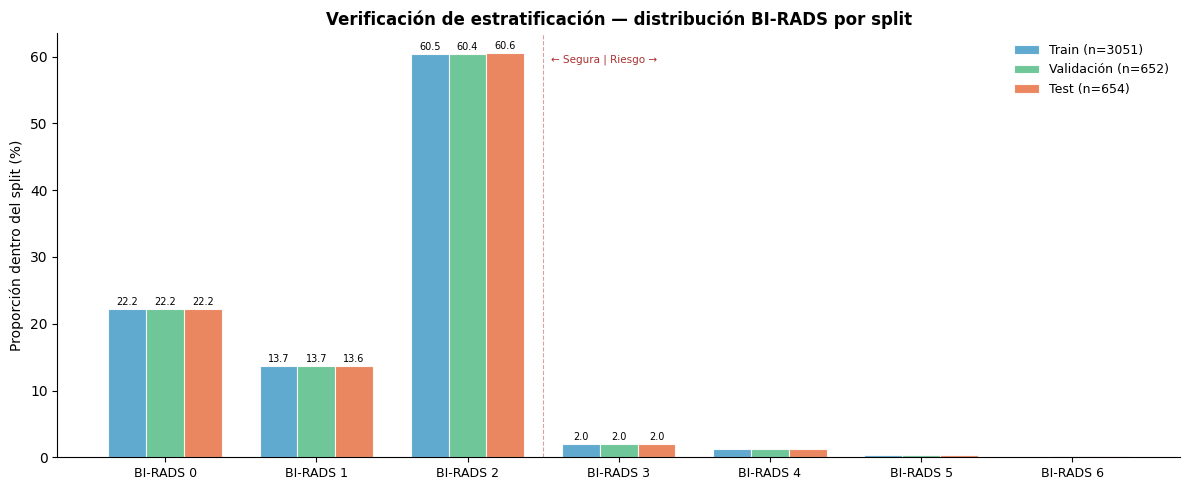

💾 Figura guardada: figures/fig4_estratificacion_splits.png
✅ Distribución proporcional uniforme entre splits confirma estratificación correcta.


In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

splits_viz    = {'Train': y_train, 'Validación': y_val, 'Test': y_test}
clases_unicas = sorted(df['BI-RADS'].unique())
x_pos         = np.arange(len(clases_unicas))
ancho         = 0.25
colores_splits = {'Train': '#4A9ECA', 'Validación': '#5BBF8A', 'Test': '#E8764A'}

for i, (nombre, labels) in enumerate(splits_viz.items()):
    conteo_split = Counter(labels)
    total_split  = len(labels)
    pcts = [conteo_split.get(c, 0) / total_split * 100 for c in clases_unicas]
    offset = (i - 1) * ancho
    bars = ax.bar(x_pos + offset, pcts, width=ancho,
                  label=f'{nombre} (n={total_split})',
                  color=colores_splits[nombre],
                  edgecolor='white', linewidth=0.8, alpha=0.88)
    for bar, p in zip(bars, pcts):
        if p > 1.5:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.3,
                    f'{p:.1f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x_pos)
ax.set_xticklabels([f'BI-RADS {c}' for c in clases_unicas], fontsize=9)
ax.set_ylabel("Proporción dentro del split (%)", fontsize=10)
ax.set_title("Verificación de estratificación — distribución BI-RADS por split",
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9, frameon=False)
ax.spines[['top','right']].set_visible(False)
ax.axvline(x=2.5, color='#AA3030', linestyle='--', linewidth=0.8, alpha=0.45)
ax.text(2.55, ax.get_ylim()[1]*0.95, '← Segura | Riesgo →',
        fontsize=7.5, color='#AA3030', va='top')

plt.tight_layout()
plt.savefig('figures/fig4_estratificacion_splits.png', dpi=300, bbox_inches='tight')
plt.show()
print("💾 Figura guardada: figures/fig4_estratificacion_splits.png")
print("✅ Distribución proporcional uniforme entre splits confirma estratificación correcta.")


## 15. Exportación trazable del dataset limpio

In [ ]:
output_path = 'data/processed/dataset_clean.csv'

columnas_export = [c for c in
    ['ID_R', 'Year', 'Age', 'BI-RADS',
     'obs_clean', 'concl_clean',
     'texto_input', 'auditor_input', 'n_tokens']
    if c in df.columns]

df[columnas_export].to_csv(output_path, index=False, encoding='utf-8')

# Hash SHA-256 para verificar integridad y reproducibilidad
with open(output_path, 'rb') as f:
    sha256 = hashlib.sha256(f.read()).hexdigest()

print(f"💾 Dataset exportado: {output_path}")
print(f"   Registros: {len(df)}")
print(f"   Columnas:  {columnas_export}")
print(f"\n🔑 SHA-256: {sha256}")
print("\n📌 IMPORTANTE: Agrega este hash SHA-256 al README.md del repositorio GitHub.")
print("   Permite verificar que cualquier ejecución futura usa exactamente el mismo")
print("   dataset limpio y reproducir los resultados del paper.")


💾 Dataset exportado: data/processed/dataset_clean.csv
   Registros: 4357
   Columnas:  ['ID_R', 'Year', 'Age', 'BI-RADS', 'obs_clean', 'concl_clean', 'texto_input', 'auditor_input', 'n_tokens']

🔑 SHA-256: e202e75f9c9f7965fe6bea4d92317d6daaa1b1d44d3ec9211e4c12989b2eee3b

📌 IMPORTANTE: Agrega este hash SHA-256 al README.md del repositorio GitHub.
   Permite verificar que cualquier ejecución futura usa exactamente el mismo
   dataset limpio y reproducir los resultados del paper.


## 16. Resumen ejecutivo de curaduría

Esta celda consolida todas las decisiones tomadas durante la curaduría.  
"critico" El contenido de esta tabla va directamente a la sección **Materiales y Métodos** del paper.


In [ ]:
print("=" * 75)
print("  RESUMEN EJECUTIVO — CURADURÍA Y PREPROCESAMIENTO")
print("  Proyecto: Sistema de Auditoría BI-RADS con BETO")
print("=" * 75)

decisiones = [
    ("Dataset original",            f"{n_antes:,} registros · 15 columnas"),
    ("Nulos en texto (eliminados)",  f"{n_antes - len(df)} registros eliminados ({(n_antes-len(df))/n_antes*100:.2f}%)"),
    ("Nulos en Age (imputados)",     "Mediana del conjunto completo pre-split"),
    ("Dataset final",               f"{len(df):,} registros"),
    ("Duplicados exactos",          f"{metricas_duplicados['dup_exactos']} en columna Observations"),
    ("Inconsistencias de etiqueta", f"{metricas_duplicados['casos_ambiguos']} textos con BI-RADS contradictorios"),
    ("Abreviaturas expandidas",     f"{len(ABREVIATURAS)} patrones clínicos"),
    ("Columna clasificador",        "texto_input = obs_clean [SEP] concl_clean"),
    ("Columna auditor",             "auditor_input = obs_clean (sin conclusión)"),
    ("Análisis de tokens",          f"Mediana {df['n_tokens'].median():.0f} · P95 {df['n_tokens'].quantile(.95):.0f} · {(df['n_tokens']>512).sum()} informes > 512 tokens ({(df['n_tokens']>512).mean()*100:.1f}%)"),
    ("Estrategia truncación",       f"{ESTRATEGIA_TRUNCACION.upper()} — head {HEAD_TOKENS} + tail {TAIL_TOKENS} tokens"),
    ("Desbalance de clases",        f"class_weight balanced (ratio {conteo.max()/conteo.min():.1f}x)"),
    ("División",                    f"70/15/15 · stratify=BI-RADS · random_state=42"),
    ("Train",                       f"{len(X_train):,} registros ({len(X_train)/len(df)*100:.1f}%)"),
    ("Validación",                  f"{len(X_val):,} registros ({len(X_val)/len(df)*100:.1f}%)"),
    ("Test",                        f"{len(X_test):,} registros ({len(X_test)/len(df)*100:.1f}%)"),
    ("Figuras generadas",           "fig1_distribucion_birads · fig2_longitud_tokens · fig3_variables_clinicas · fig4_estratificacion_splits"),
    ("Dataset exportado",           f"data/processed/dataset_clean.csv"),
    ("SHA-256",                     sha256),
]

for etapa, resultado in decisiones:
    print(f"  {etapa:35s}  {resultado}")

print("=" * 75)
print("\n✅ Curaduría completada. El dataset está listo para la fase experimental.")
print("   Próximo paso: Baseline con TF-IDF + XGBoost / Random Forest")


  RESUMEN EJECUTIVO — CURADURÍA Y PREPROCESAMIENTO
  Proyecto: Sistema de Auditoría BI-RADS con BETO
  Dataset original                     4,357 registros · 15 columnas
  Nulos en texto (eliminados)          0 registros eliminados (0.00%)
  Nulos en Age (imputados)             Mediana del conjunto completo pre-split
  Dataset final                        4,357 registros
  Duplicados exactos                   959 en columna Observations
  Inconsistencias de etiqueta          8 textos con BI-RADS contradictorios
  Abreviaturas expandidas              16 patrones clínicos
  Columna clasificador                 texto_input = obs_clean [SEP] concl_clean
  Columna auditor                      auditor_input = obs_clean (sin conclusión)
  Análisis de tokens                   Mediana 166 · P95 259 · 0 informes > 512 tokens (0.0%)
  Estrategia truncación                HEAD_TAIL — head 128 + tail 384 tokens
  Desbalance de clases                 class_weight balanced (ratio 527.0x)
  División  